(learning)=
# Deep Bayesian predictive coding

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ComputationalPsychiatry/pyhgf/blob/master/docs/source/notebooks/0.5-Learning.ipynb)

In [1]:
import sys

from IPython.utils import io

if "google.colab" in sys.modules:
    with io.capture_output() as captured:
        ! pip uninstall -y jax jaxlib
        ! pip install pyhgf watermark jax[cuda12]==0.4.31

In [2]:
import jax
import jax.numpy as jnp
import matplotlib.animation as animation
import matplotlib.pyplot as plt
import numpy as np
import optax
import seaborn as sns
import treescope
from IPython.display import HTML
from jax.nn import leaky_relu

from pyhgf.model import DeepNetwork
from pyhgf.plots.graphviz.plot_network import plot_deep_network

np.random.seed(123)
plt.rcParams["figure.constrained_layout.use"] = True

treescope.basic_interactive_setup(autovisualize_arrays=True)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


```{warning}
The features exposed here are still a work in progress.
```

The hierarchical Gaussian filter is built on top of a generative model that is governed by Gaussian random walks, which is best used to model the time-resolved evolution of beliefs in volatile environments. But the framework can easily extend to traditional applications of predictive coding, such as deep neural networks, where the variational message passing replaces the use of iterative gradient descent during inference.

In this notebook, we show that the **prospective configuration** in predictive coding networks can be performed by one-shot variational updates, removing the need for gradient descent over the energy function, while learning expected precision in the hidden layers, which is often fixed in other approaches. We illustrate this with the "bear example" from {cite:p}`Song2024` and on a classification task with deep networks.

```{figure} https://media.springernature.com/full/springer-static/image/art%3A10.1038%2Fs41593-023-01514-1/MediaObjects/41593_2023_1514_Fig1_HTML.png?as=webp
---
name: learning-prospective-config-task
---
Learning with prospective configuration.

```

## Learning in deep networks

### Prospective configuration

In standard backpropagation, weights are updated using gradients computed from a fixed forward pass. The network's activations are "frozen" while the error signal propagates backward. **Prospective configuration** {cite:p}`Song2024` takes a different approach: before any weight change, the network first *infers* the most likely activations at every layer by settling prediction errors across the whole hierarchy. Only once this inference step has converged are the weights updated. This two-phase process (infer activations, then update weights) prevents the catastrophic interference that arises when a local weight change inadvertently distorts representations elsewhere in the network.

In `pyhgf`, this is implemented naturally through the belief propagation cycle. At each observation:

1. **Prediction**: predictors ($x$) are provided in the leaf nodes. Each node generates a top-down prediction for its children via a nonlinear coupling function $g(\cdot)$.
2. **Observation & prediction errors**: the observed values ($y$) are compared with predictions, and precision-weighted prediction errors propagate upward through the hierarchy.
3. **Posterior update**: node activations (means and precisions) are updated to minimise free energy, settling the network into a new equilibrium. This is comparable to the *prospective configuration* step.
4. **Weight update**: only after the activations have settled are the coupling strengths (weights) adjusted using the prediction errors and the inferred activations.

We illustrate this using the "bear" example network from {cite:t}`Song2024`.

In [3]:
# here x represents the visual input (River / No River)
x = np.array([1.0, 1.0] * 120)
x += np.random.normal(size=x.shape) / 100

# y represents the auditory and olfactory stimuli
y = np.array([
    x,
    np.concat([
        np.array([1.0, 1.0] * 40),
        np.array([-1.0, -1.0] * 40),
        np.array([1.0, 1.0] * 40),
    ])
    + np.random.normal(size=x.shape) / 100,
]).T

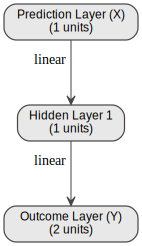

In [4]:
# We start by defining a simple two-branch deep network.
# The output layer (leaves) receives the outcomes ``y``; the top layer
# receives the predictor ``x``, with a shared latent layer in between.
network = (
    DeepNetwork()
    .add_layer(size=2, precision=2.0, expected_precision=2.0)  # outcomes (y)
    .add_layer(size=1)  # shared latent
    .add_layer(size=1, precision=1.0, expected_precision=1.0)  # predictor (x)
)
plot_deep_network(network)

Deep networks trained for classification purposes differ from other predictive coding networks as both roots and leaves should receive inputs (predictors and outcomes, respectively).

In [5]:
network.fit(
    x=x.reshape(-1, 1),
    y=y,
    optimizer=optax.sgd(0.2),
    learning_kind="standard",
    record=("expected_mean",),
    time_step=1.0,
);

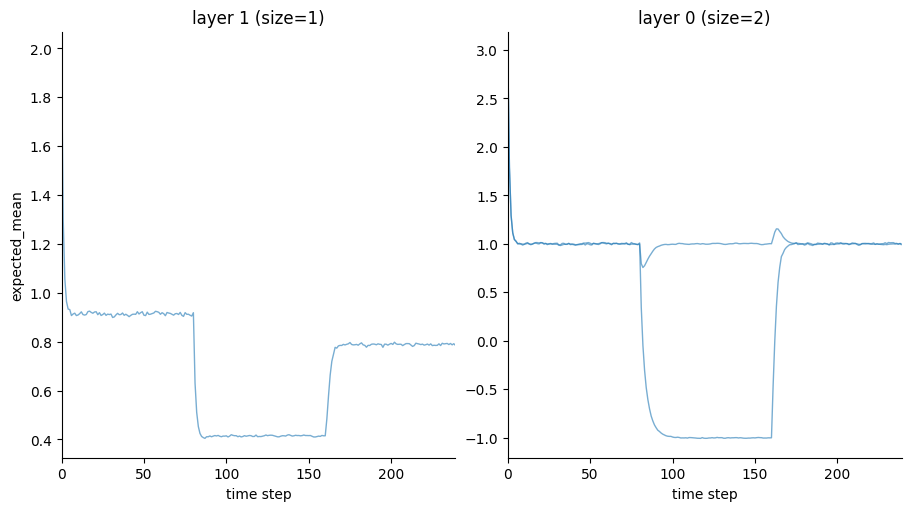

In [6]:
# Expected mean of the shared latent layer (1) and the outcome layer (0).
network.plot_layers(
    layers=[1, 0],
    variables=("expected_mean",),
    figsize=(9, 5),
)
sns.despine();

This example illustrates the effectiveness of the variational update to replace the prospective configuration step based on gradient descent. As new observations contradict the expected outcomes (i.e., observing the river without hearing the water, from trials 40 to 80 in the bottom panel), the network efficiently reorganizes without interfering with other predictions (i.e,. still expecting smelling the salmon while seeing the water, top panel, trials 40 to 80).

```{hint} Volatile state nodes
In a predictive coding network, two types of state nodes can be used to build the hierarchy. Continuous-state nodes are the standard HGF nodes: their precision is controlled by external volatility parents connected through dedicated volatility edges, and their mean persists across time steps by default (`autoconnection_strength`=1.0). This makes them well-suited for tracking slowly drifting quantities or serving as input/output layers that receive observations. Volatile-state nodes bundle a value level and an internal volatility level into a single node, removing the need for separate volatility parents. Their mean resets at each time step by default (`autoconnection_strength`=0.0), making them behave like stateless hidden units whose activation is determined entirely by incoming predictions. In practice, volatile-state nodes are the natural building block for hidden layers in deep predictive coding networks; they are more parameter-efficient than continuous-state nodes because the volatility coupling is handled internally, and their stateless default mirrors the feedforward activations of a conventional neural network.
```

### Weight update

Once the network has settled into its new posterior (the prospective configuration step), the coupling strengths $w_i$ between a child node and its value parents are updated. Let $\text{PE}$ denote the value prediction error at the child node, $\pi_{\text{child}}$ its posterior precision, and $g(\mu_i)$ the activation of parent $i$ passed through the coupling function $g$.

**Fixed learning rate.** With a constant step size $\eta$:

$$
\Delta w_i \;=\; \eta \;\cdot\; \text{PE} \;\cdot\; \pi_{\text{child}} \;\cdot\; g(\mu_i)
$$

**Dynamic (precision-weighted) learning rate.** When no fixed rate is specified, the update uses a Kalman-gain-like rule that automatically scales the step size by the relative precision of parent and child:

$$
K_i = \frac{\pi_{\text{parent}_i}}{\pi_{\text{parent}_i} + \pi_{\text{child}}}
$$

$$
\Delta w_i \;=\; K_i \;\cdot\; \text{PE} \;\cdot\; g(\mu_i)
$$

In the dynamic case, precise parents exert a larger influence on the weight update while uncertain parents are updated more cautiously. This same precision weighting governs how far each clamped signal propagates through the hierarchy — the depth-dependent effect explored interactively in the next section.

### Input precision controls the depth of weight updates

One natural consequence that emerges from this framework is that neural activations are defined by their precision, and as a result, the precision of the inputs (both predictors and outcomes) controls the strengths of prediction errors and the amplitude of weight updates in the vicinity of information flows. For example, more precise outcomes will guide weight updates to be larger at the nodes close to the inputs, and a more precise predictor will guide weight updates to be larger close to the internal representation.

The widget below makes this explicit. We stack **eight** continuous-state value-parent layers through linear coupling and clamp the two ends: the **root** (layer 0) to an outcome $y = 1$ and the **leaf** (top layer) to an input $X = 0$. The two sliders set the *expected precision* of these clamped ends; every other prior is held fixed. Ten belief-propagation iterations are then run with the weights **frozen**, so only the means and precisions move — letting us watch how far each clamp's influence reaches across the stack.

- **Left** — activations per layer. The ✕ markers are the prediction $\hat\mu$ after the first iteration; the ``Greys``-coloured polylines trace the posterior $\mu$ across layers at each iteration (light = early, dark = late).
- **Middle / Right** — predicted $\mathcal{N}(\hat\mu,\ 1/\hat\pi)$ and posterior $\mathcal{N}(\mu,\ 1/\pi)$ belief ridges at the final iteration.

Every panel auto-zooms to the currently selected state.

```{note}
The published page has no live Python kernel, so the figure is **pre-computed** on a grid of root/leaf precisions $\in \{0.1, 0.5, 1, 5, 10, 100, 500, 1000\}$ ($8 \times 8 = 64$ states) and embedded as a self-contained Bokeh (HTML + JS) widget. The sliders snap to those grid values; move either of them to see the belief propagation re-equilibrate.
```

In [7]:
import numpy as np
import optax
import seaborn as sns
from bokeh.embed import file_html
from bokeh.layouts import column, row
from bokeh.models import (
    ColorBar,
    ColumnDataSource,
    CustomJS,
    CustomJSTickFormatter,
    DataRange1d,
    Label,
    LinearColorMapper,
    Slider,
    Span,
)
from bokeh.plotting import figure
from bokeh.resources import CDN
from IPython.display import HTML

from pyhgf.model import DeepNetwork

# --- Static grid the sliders snap to (the built page has no live kernel, so
# every (root, leaf) combination below is computed once, here, at build
# time and embedded into the widget). ---
N_LAYERS, N_ITER, RIDGE_H, N_GRID = 8, 10, 0.7, 400
ROOT_VALS = [0.1, 0.5, 1.0, 5.0, 10.0, 100.0, 500.0, 1000.0]
LEAF_VALS = [0.1, 0.5, 1.0, 5.0, 10.0, 100.0, 500.0, 1000.0]
DEFAULT_ROOT_IDX = DEFAULT_LEAF_IDX = 4  # 10.0 / 10.0


def _linear(x):
    return x


# ``run_scan`` is ``eqx.filter_jit``-ed with the optimizer as a *static* cache
# key, so reuse one instance across the grid (a fresh ``optax.sgd`` per state
# would recompile and cache an executable for every state).
_OPT = optax.sgd(0.0)


def _run(root_prec, leaf_prec):
    """Clamp y=1 at the root and X=0 at the leaf, then settle for N_ITER steps."""
    # ``_linear`` is a single shared object: ``coupling_fn`` is a static field,
    # so reusing it lets JAX compile ``run_scan`` once and reuse it across the
    # whole grid (a fresh ``lambda`` per call would recompile for every state).
    net = DeepNetwork(coupling_fn=_linear, volatility_updates="standard")
    for i in range(N_LAYERS):
        prec = root_prec if i == 0 else leaf_prec if i == N_LAYERS - 1 else 100.0
        # Every layer is frozen (no volatility parent): the beliefs are shaped
        # purely by the two precision clamps propagating through the stack.
        net.add_layer(
            size=1,
            add_constant_input=False,
            volatility_parent=False,
            precision=prec,
            expected_precision=prec,
        )
    net.fit(
        np.zeros((N_ITER, 1)),
        np.ones((N_ITER, 1)),
        optimizer=_OPT,  # weights frozen below; this is inert
        weight_update=False,
        record=("mean", "precision", "expected_mean", "expected_precision"),
        time_step=1.0,
    )
    t = net.trajectories
    stack = lambda f: np.stack([np.asarray(t[f][L]).ravel() for L in range(N_LAYERS)])
    return (
        stack("mean"),
        stack("precision"),
        stack("expected_mean"),
        stack("expected_precision"),
    )


# --- Pre-compute every grid point: state index s = ri*NL + li ---
EF, SNAP, MFIN, SPOST, MPRED, SPRED, DS, XLO, XHI = ([] for _ in range(9))
for root in ROOT_VALS:
    for leaf in LEAF_VALS:
        means, precs, emeans, eprecs = _run(root, leaf)
        sig_post = 1.0 / np.sqrt(np.clip(precs[:, -1], 1e-12, None))
        sig_pred = 1.0 / np.sqrt(np.clip(eprecs[:, -1], 1e-12, None))
        EF.append(emeans[:, 0].tolist())
        SNAP.append(means.tolist())  # (L, T)
        MFIN.append(means[:, -1].tolist())
        SPOST.append(sig_post.tolist())
        MPRED.append(emeans[:, -1].tolist())
        SPRED.append(sig_pred.tolist())
        # Per-state density scale: the tallest Gaussian *in this state*
        # (across both ridge panels) fills exactly one ridge slot, so the
        # y-axis always fits the tallest distribution as the sliders move.
        # Heights stay true densities within a view (taller + narrower =
        # more precise); only the absolute scale is re-fit per state.
        peak = max(
            float(1.0 / (sig_post.min() * np.sqrt(2 * np.pi))),
            float(1.0 / (sig_pred.min() * np.sqrt(2 * np.pi))),
        )
        DS.append(RIDGE_H / peak)
        # Per-state x extent for the ridge panels (capped padding) so each
        # panel's DataRange1d zooms to the beliefs of the selected state.
        sc = min(2.0, max(sig_post.max(), sig_pred.max()))
        lo = min(means[:, -1].min(), emeans[:, -1].min()) - 3 * sc
        hi = max(means[:, -1].max(), emeans[:, -1].max()) + 3 * sc
        XLO.append(float(min(lo, 0.0)))
        XHI.append(float(max(hi, 1.0)))

LAYER_COLORS = sns.color_palette("rocket", N_LAYERS).as_hex()
# Greys, darker for later iterations; drop the two lightest so early lines stay
# visible on the white background.
ITER_COLORS = sns.color_palette("Greys", N_ITER + 2).as_hex()[2:]
layer_idx = list(range(N_LAYERS))
s0 = DEFAULT_ROOT_IDX * len(LEAF_VALS) + DEFAULT_LEAF_IDX


def _ridges(mfin, sfin, ds, xlo, xhi):
    # True Gaussian density scaled by the per-state ``ds``: a more precise layer
    # is both taller and narrower, and the tallest fills one ridge slot.
    grid = np.linspace(xlo, xhi, N_GRID)
    xs, ys, mx, my1 = [], [], [], []
    for i in range(N_LAYERS):
        ridge = (
            ds
            * (1.0 / (sfin[i] * np.sqrt(2 * np.pi)))
            * np.exp(-0.5 * ((grid - mfin[i]) / sfin[i]) ** 2)
        )
        xs.append(grid.tolist() + grid[::-1].tolist())
        ys.append((i + ridge).tolist() + [i] * N_GRID)
        mx.append(mfin[i])
        my1.append(i + float(ridge.max()))
    return xs, ys, mx, my1


src_pred = ColumnDataSource(dict(x=EF[s0], y=layer_idx, color=LAYER_COLORS))
snap0 = np.array(SNAP[s0])
src_lines = ColumnDataSource(
    dict(
        xs=[snap0[:, t].tolist() for t in range(N_ITER)],
        ys=[layer_idx for _ in range(N_ITER)],
        color=ITER_COLORS,
    )
)
xp, yp, mxp, myp = _ridges(MPRED[s0], SPRED[s0], DS[s0], XLO[s0], XHI[s0])
xq, yq, mxq, myq = _ridges(MFIN[s0], SPOST[s0], DS[s0], XLO[s0], XHI[s0])
src_rpred = ColumnDataSource(dict(xs=xp, ys=yp, color=LAYER_COLORS))
src_rpost = ColumnDataSource(dict(xs=xq, ys=yq, color=LAYER_COLORS))
src_mpred = ColumnDataSource(
    dict(x0=mxp, x1=mxp, y0=layer_idx, y1=myp, color=LAYER_COLORS)
)
src_mpost = ColumnDataSource(
    dict(x0=mxq, x1=mxq, y0=layer_idx, y1=myq, color=LAYER_COLORS)
)

# DataRange1d so every panel auto-zooms to the currently displayed state. The
# y-axis (layers) is shared across panels; the ridge panels share their x-axis.
y_shared = DataRange1d()
x_ridge = DataRange1d()
p0 = figure(
    width=380,
    height=480,
    x_range=DataRange1d(),
    y_range=y_shared,
    title="Activations",
    x_axis_label="activation",
    y_axis_label="layer (0 = root, top = leaf)",
)
p0.multi_line(
    "xs", "ys", line_color="color", line_width=1.4, alpha=0.9, source=src_lines
)
p0.scatter(
    "x",
    "y",
    source=src_pred,
    size=12,
    marker="x",
    line_color="color",
    line_width=2.5,
    legend_label="prediction μ̂ (iter 1)",
)
p0.add_layout(
    Span(location=0.0, dimension="height", line_color="gray", line_dash="dotted")
)
p0.add_layout(
    Span(location=1.0, dimension="height", line_color="gray", line_dash="dotted")
)
p0.add_layout(
    Label(
        x=0.0, y=N_LAYERS - 0.4, text="X = 0", text_color="gray", text_font_size="9pt"
    )
)
p0.add_layout(
    Label(x=1.0, y=-0.8, text="y = 1", text_color="gray", text_font_size="9pt")
)
p0.legend.location, p0.legend.label_text_font_size = "top_left", "8pt"
p0.add_layout(
    ColorBar(
        color_mapper=LinearColorMapper(palette=ITER_COLORS, low=1, high=N_ITER),
        title="iteration",
        height=8,
    ),
    "below",
)
p1 = figure(
    width=360,
    height=480,
    x_range=x_ridge,
    y_range=y_shared,
    title="Expected mean and precision",
    x_axis_label="activation",
)
p1.patches(
    "xs",
    "ys",
    source=src_rpred,
    fill_color="color",
    fill_alpha=0.35,
    line_color="color",
)
p1.segment(
    "x0", "y0", "x1", "y1", source=src_mpred, line_color="color", line_dash="dotted"
)
p2 = figure(
    width=360,
    height=480,
    x_range=x_ridge,
    y_range=y_shared,
    title="Posterior  mean and precision",
    x_axis_label="activation",
)
p2.patches(
    "xs",
    "ys",
    source=src_rpost,
    fill_color="color",
    fill_alpha=0.35,
    line_color="color",
)
p2.segment(
    "x0", "y0", "x1", "y1", source=src_mpost, line_color="color", line_dash="dotted"
)

fmt_root = CustomJSTickFormatter(
    args=dict(v=ROOT_VALS), code="return v[tick].toString();"
)
fmt_leaf = CustomJSTickFormatter(
    args=dict(v=LEAF_VALS), code="return v[tick].toString();"
)
s_root = Slider(
    start=0,
    end=len(ROOT_VALS) - 1,
    step=1,
    value=DEFAULT_ROOT_IDX,
    title="Root precision",
    format=fmt_root,
    width=420,
)
s_leaf = Slider(
    start=0,
    end=len(LEAF_VALS) - 1,
    step=1,
    value=DEFAULT_LEAF_IDX,
    title="Leaf precision",
    format=fmt_leaf,
    width=420,
)
cb = CustomJS(
    args=dict(
        src_pred=src_pred,
        src_lines=src_lines,
        src_rpred=src_rpred,
        src_rpost=src_rpost,
        src_mpred=src_mpred,
        src_mpost=src_mpost,
        s_root=s_root,
        s_leaf=s_leaf,
        EF=EF,
        SNAP=SNAP,
        MFIN=MFIN,
        SPOST=SPOST,
        MPRED=MPRED,
        SPRED=SPRED,
        XLO=XLO,
        XHI=XHI,
        DS=DS,
        NL=N_LAYERS,
        NT=N_ITER,
        NG=N_GRID,
        NLEAF=len(LEAF_VALS),
    ),
    code="""
    const s = s_root.value * NLEAF + s_leaf.value;
    src_pred.data['x'] = EF[s];
    const xs = [];
    for (let t = 0; t < NT; t++) { const r = []; for (let L = 0; L < NL; L++) r.push(SNAP[s][L][t]); xs.push(r); }
    src_lines.data['xs'] = xs;
    const xlo = XLO[s], xhi = XHI[s], SQ2PI = Math.sqrt(2 * Math.PI), ds = DS[s];
    const grid = []; for (let k = 0; k < NG; k++) grid.push(xlo + (xhi - xlo) * k / (NG - 1));
    // True Gaussian density scaled by the per-state ds (the tallest Gaussian in
    // the state fills one slot): a more precise layer is both taller and narrower.
    function ridges(mfin, sfin) {
        const Xs = [], Ys = [], x0 = [], y1 = [];
        for (let i = 0; i < NL; i++) {
            const top = [], mu = mfin[i], sig = sfin[i]; let rmax = 0;
            for (let k = 0; k < NG; k++) {
                const d = ds * (1.0 / (sig * SQ2PI)) * Math.exp(-0.5 * Math.pow((grid[k] - mu) / sig, 2));
                top.push(i + d); if (d > rmax) rmax = d;
            }
            const base = []; for (let k = 0; k < NG; k++) base.push(i);
            Xs.push(grid.concat(grid.slice().reverse())); Ys.push(top.concat(base));
            x0.push(mu); y1.push(i + rmax);
        }
        return [Xs, Ys, x0, y1];
    }
    let r = ridges(MPRED[s], SPRED[s]);
    src_rpred.data['xs'] = r[0]; src_rpred.data['ys'] = r[1];
    src_mpred.data['x0'] = r[2]; src_mpred.data['x1'] = r[2]; src_mpred.data['y1'] = r[3];
    r = ridges(MFIN[s], SPOST[s]);
    src_rpost.data['xs'] = r[0]; src_rpost.data['ys'] = r[1];
    src_mpost.data['x0'] = r[2]; src_mpost.data['x1'] = r[2]; src_mpost.data['y1'] = r[3];
    for (const src of [src_pred, src_lines, src_rpred, src_rpost, src_mpred, src_mpost]) src.change.emit();
    """,
)
for sld in (s_root, s_leaf):
    sld.js_on_change("value", cb)

layout = column(row(p0, p1, p2), s_root, s_leaf)
html = file_html(layout, CDN, "Reactive value-parent stack")
# Isolate the standalone document in an iframe so its BokehJS <script> tags
# survive the static HTML build (no live kernel needed). Wrapped in a <div>
# so the cell output does not start with <iframe> (avoids an IPython warning).
_srcdoc = html.replace("&", "&amp;").replace('"', "&quot;")
out = HTML(
    '<div class="bokeh-widget">'
    f'<iframe srcdoc="{_srcdoc}" width="100%" height="620" '
    'style="border:none;" loading="lazy"></iframe></div>'
)
out

#### Interpretation tips

- When the **root precision** is high (e.g. 100+) the observation $y = 1$ pulls the bottom layer's posterior hard towards 1, and successive layers blend that signal upward with the broad interior priors.
- When the **leaf precision** is high the input $X = 0$ pulls the top layer hard towards 0; the bottom layer is then torn between the two clamps and the gradient of beliefs across the stack reveals where the information flow stalls.
- When **both clamps are weak** the interior priors dominate and every layer relaxes near its predicted mean.
- Each Gaussian ridge is a true Gaussian density whose height is auto-scaled per view so the **tallest distribution fills one slot** (within a view, a more precise belief is both taller and narrower). Compare the predicted vs. posterior ridges to see how much each layer was sharpened by the bottom-up sweep.

## Building Deep-Network Structures in pyhgf

### Backends

As of version `0.2.9`, **PyHGF** supports the creation of deep neural networks for classification tasks using:

- {py:class}`pyhgf.model.Network`: using the standard network class. Deep networks have to be built manually using {py:class}`pyhgf.model.Network.add_nodes`. This approach is more flexible, but will rapidly struggle with large structures (> 20 nodes) as each update function is cached by JAX.
- {py:class}`pyhgf.rshgf.Network`: is the Rust equivalent and will scale efficiently to larger structures, while remaining flexible in the network configuration. It supports layered designs with {py:meth}`pyhgf.rshgf.Network.add_layer`. It is not differentiable.
- {py:class}`pyhgf.model.DeepNetwork`: is a vectorised JAX implementation, differentiable, and the fastest solution.

Here, we demonstrate two new high-level functions for constructing layered, fully connected value-parent structures in `pyhgf`:

- **`add_layer()`** – adds a *single* fully connected parent layer.
- **`add_layer_stack()`** – builds *multiple* layers at once, similar to `Sequential` in deep-learning frameworks.

These functions allow HGF models to be composed in a deep-network style while remaining fully compatible with the probabilistic belief-update dynamics.

### Adding fully connected Layers with `add_layer`

`add_layer` provides fine-grained control, letting you manually construct each layer.

This is useful when each layer should have different hyperparameters (precision, volatility-level tonic volatility, etc.). The function creates a fully connected parent layer, in which each parent node connects to all children below it.

By default, `add_layer` automatically connects to all orphan nodes (nodes without value parents). You can also specify `value_children` explicitly to control which nodes the layer connects to.

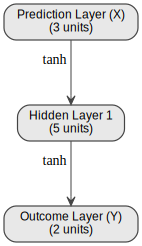

In [8]:
# Or chain them in a single expression (like Keras/PyTorch):
net = (
    DeepNetwork(coupling_fn=jnp.tanh)
    .add_layer(size=2)
    .add_layer(size=5, tonic_volatility_vol=-1.0)
    .add_layer(size=3, tonic_volatility_vol=-2.0)
)

# Visualize the network structure
plot_deep_network(net)

### Adding multiple layers with `add_layer_stack`

`add_layer_stack` provides a compact way to build several fully connected parent layers at once. Instead of adding each layer manually, you simply specify the desired layer sizes (e.g., [3, 16, 32]), and the function creates them sequentially. Each layer is fully connected to the one below, using the same hyperparameters for all layers you add (precision, volatility-level tonic volatility, etc.).

This is ideal when you want to quickly prototype deep hierarchical networks or mimic the "stacked layer" construction found in deep learning frameworks.

Like `add_layer`, it also supports method chaining and auto-connects to orphan nodes by default.

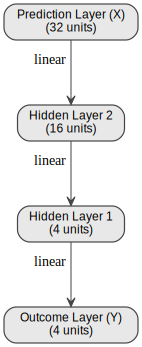

In [9]:
# Add 3 fully connected parent layers (4→4→16→32) using method chaining
net = (
    DeepNetwork()
    .add_layer(size=4)
    .add_layer_stack(
        layer_sizes=[4, 16, 32],
        tonic_volatility_vol=-1.0,
    )
)

plot_deep_network(net)

Deep networks often require weights to be initialised using strategies that conserve the balance of variance in the inputs and output nodes. The classes have a {py:meth}`pyhgf.DeepNetwork.weight_initialisation` method that supports the most popular strategies.

In [10]:
net.weight_initialisation(strategy="he");

## Multiclass classification on a three-branch spiral

We now demonstrate `DeepNetwork` on a non-linearly separable *multiclass* problem: a **three-branch spiral** — three interleaving Archimedean spiral arms offset by 120°, one arm per class. We train a **2 → 8 × 4 → 3 (categorical)** predictive-coding network with `leaky_relu` coupling functions and a **categorical** output layer, using the Adam optimiser. After training, we visualise how the three-way decision boundary evolves across epochs.

A categorical output layer differs from the binary one used for two classes. A binary layer holds one *independent* Bernoulli belief per node; a categorical layer treats its `size` nodes as a *single* joint choice among mutually exclusive classes. Its expected mean is the **softmax** across the layer, so the three class probabilities compete and sum to one. The target clamped during training is a **one-hot** vector (a 1 in the true class, 0 elsewhere), and the resulting value prediction error $\delta = \mathrm{one\_hot} - \mathrm{softmax}$ is exactly the cross-entropy gradient in logit space.

### Generate the dataset

We build the three arms by sweeping a radius that grows with the angle and offsetting each arm by 120°, then add Gaussian noise. Each arm is one class. We split the 900 samples into 80% training / 20% test and pre-compute the mesh grid used for the decision-boundary heatmap.

In [ ]:
# --- Three-branch spiral dataset ---
def make_three_spirals(n_samples=900, noise=0.06, n_turns=1.25, r_max=2.0, seed=42):
    """Three interleaving Archimedean spiral arms at 120° offsets (one per class)."""
    rng = np.random.default_rng(seed)
    n = n_samples // 3
    xs, ys = [], []
    for k in range(3):
        t = np.linspace(0.0, 1.0, n)
        r = 0.2 + (r_max - 0.2) * t  # radius grows along the arm
        theta = 2.0 * np.pi * n_turns * t + 2.0 * np.pi * k / 3.0  # 120° offset per arm
        arm = np.column_stack([r * np.cos(theta), r * np.sin(theta)])
        xs.append(arm + rng.normal(scale=noise, size=arm.shape))
        ys.append(np.full(n, k))
    X = np.vstack(xs)
    y = np.concatenate(ys)
    idx = rng.permutation(len(X))
    return X[idx].astype(np.float32), y[idx].astype(np.int32)


N_CLASSES = 3
N_SAMPLES = 900
X_spiral, y_spiral = make_three_spirals(n_samples=N_SAMPLES, noise=0.06, seed=42)

# Train / test split (80 / 20)
n_train = int(0.8 * N_SAMPLES)
X_train_s, X_test_s = X_spiral[:n_train], X_spiral[n_train:]
y_train_s, y_test_s = y_spiral[:n_train], y_spiral[n_train:]

# One-hot targets clamped on the categorical output layer.
Y_train_oh = np.eye(N_CLASSES, dtype=np.float32)[y_train_s]
Y_test_oh = np.eye(N_CLASSES, dtype=np.float32)[y_test_s]

# Mesh grid for the decision boundary
h = 0.03
x_min, x_max = X_spiral[:, 0].min() - 0.5, X_spiral[:, 0].max() + 0.5
y_min, y_max = X_spiral[:, 1].min() - 0.5, X_spiral[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
grid = jnp.array(np.column_stack([xx.ravel(), yy.ravel()]), dtype=jnp.float32)

print(f"Training: {X_train_s.shape[0]} samples  |  Test: {X_test_s.shape[0]} samples")
print(f"Grid points: {grid.shape[0]:,}")

In [ ]:
# Class colours from the seaborn deep palette (blue, red, green)
_deep = sns.color_palette("deep").as_hex()
CLASS_COLORS = [_deep[0], _deep[3], _deep[2]]

fig, ax = plt.subplots(figsize=(5, 5))
for cls, color in enumerate(CLASS_COLORS):
    mask = y_spiral == cls
    ax.scatter(
        X_spiral[mask, 0],
        X_spiral[mask, 1],
        marker="o",
        s=20,
        edgecolors="k",
        linewidths=0.5,
        c=color,
        label=f"Class {cls}",
    )
ax.set(xlabel="$x_1$", ylabel="$x_2$", title="Three-Branch Spiral Dataset")
ax.set_aspect("equal")
ax.legend()
plt.minorticks_on()
sns.despine()

### Build the network

We construct a `DeepNetwork` with `leaky_relu` coupling functions and He weight initialisation. The categorical output layer of size `N_CLASSES` applies a softmax internally, producing a probability distribution over the three classes directly.

In [ ]:
# Build: 2 → 8 × 4 → 3 (categorical output)
clf_net = DeepNetwork(coupling_fn=leaky_relu).add_layer(
    size=N_CLASSES, kind="categorical"
)

for _ in range(4):
    clf_net.add_layer(size=8, tonic_volatility_vol=-8.0)

clf_net = clf_net.add_layer(
    size=2,
    add_constant_input=False,
    coupling_fn=lambda x: x,
    expected_precision=10e9,
).weight_initialisation("he", key=jax.random.key(0))

print(f"Layers: {clf_net.n_layers}  |  Nodes: {clf_net.n_nodes}")

### Train over multiple epochs

We train for 80 epochs using the Adam optimiser and snapshot the decision boundary at every epoch. The loss is the **categorical cross-entropy** between the one-hot targets and the softmax predictions; accuracy is the fraction of samples whose highest-probability class (`argmax`) matches the label.

In [ ]:
NUM_EPOCHS = 80
SNAPSHOT_EVERY = 3
TIME_STEP = 0.001

# Prepare JAX arrays
jax_X_train = jnp.array(X_train_s)
jax_Y_train = jnp.array(Y_train_oh)
jax_X_test = jnp.array(X_test_s)


def cce(probs, one_hot, eps=1e-7):
    """Categorical cross-entropy from probabilities and one-hot targets."""
    p = np.clip(probs, eps, 1.0)
    return -np.mean(np.sum(one_hot * np.log(p), axis=1))


train_losses, test_losses = [], []
train_accs, test_accs = [], []
snapshots = {}  # epoch → (H, W, N_CLASSES) softmax grid

adam = optax.adam(1e-3)

for epoch in range(NUM_EPOCHS):
    # Evaluate on test set (forward pass, no weight updates)
    test_preds = np.array(clf_net.predict(jax_X_test))
    test_losses.append(cce(test_preds, Y_test_oh))
    test_accs.append(np.mean(test_preds.argmax(axis=1) == y_test_s))

    # Train: one full pass through the training set
    clf_net.fit(
        jax_X_train,
        jax_Y_train,
        optimizer=adam,
        learning_kind="standard",
        time_step=TIME_STEP,
    )

    # Training metrics from the predictions recorded during this epoch
    train_preds = np.array(clf_net.predictions)
    train_losses.append(cce(train_preds, Y_train_oh))
    train_accs.append(np.mean(train_preds.argmax(axis=1) == y_train_s))

    # Snapshot decision boundary (full softmax over the grid)
    if epoch % SNAPSHOT_EVERY == 0 or epoch == NUM_EPOCHS - 1:
        grid_probs = np.array(clf_net.predict(grid))
        snapshots[epoch] = grid_probs.reshape(xx.shape[0], xx.shape[1], N_CLASSES)

    if epoch % 10 == 0 or epoch == NUM_EPOCHS - 1:
        print(
            f"Epoch {epoch:>3d} | "
            f"train loss={train_losses[-1]:.4f}, acc={train_accs[-1]:.3f} | "
            f"test  loss={test_losses[-1]:.4f}, acc={test_accs[-1]:.3f}"
        )

print(f"\nSaved {len(snapshots)} decision boundary snapshots")

### Training curves

In [ ]:
deep = sns.color_palette("deep")

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

axs[0].plot(train_losses, label="Train", alpha=0.8, color=deep[0])
axs[0].plot(test_losses, label="Test", alpha=0.8, color=deep[3])
axs[0].set(xlabel="Epoch", ylabel="Categorical Cross-Entropy", title="Loss")
axs[0].legend()
axs[0].grid(linestyle="--")

axs[1].plot(train_accs, label="Train", alpha=0.8, color=deep[0])
axs[1].plot(test_accs, label="Test", alpha=0.8, color=deep[3])
axs[1].set(xlabel="Epoch", ylabel="Accuracy", title="Accuracy")
axs[1].legend()
axs[1].grid(linestyle="--")

sns.despine()

### Decision boundary evolution

We animate the three-way decision boundary across training epochs. Each grid cell is coloured by its `argmax` class and faded toward white where the network is unsure — that is, where the largest softmax probability is close to the $1/3$ chance level.

```{figure} ../images/three_spirals_training.gif
---
name: three-spirals-animation
---
The GIF shows how the predictive coding network gradually carves out three interleaving regions to separate the spiral arms. Colour marks the argmax class; the fade toward white flags low-confidence zones where the softmax is close to uniform.
```

In [ ]:
# Uncomment this part to create an animation of decision boundaries across epochs

# from matplotlib.colors import to_rgb
#
# # Fixed base colour per class; a grid cell fades from its class colour (certain)
# # toward white (softmax at the 1/3 chance level).
# base_rgb = np.array([to_rgb(c) for c in CLASS_COLORS])  # (N_CLASSES, 3)
# chance = 1.0 / N_CLASSES
#
#
# def boundary_rgb(prob_grid):
#     """Map an (H, W, N_CLASSES) softmax grid to an RGB image."""
#     cls = prob_grid.argmax(axis=2)
#     conf = prob_grid.max(axis=2)
#     conf_n = np.clip((conf - chance) / (1.0 - chance), 0.0, 1.0)
#     rgb = base_rgb[cls]
#     return 1.0 - (1.0 - rgb) * conf_n[..., None]  # fade toward white where unsure
#
#
# # Morph between consecutive snapshots by blending their softmax grids, so the
# # boundary glides continuously instead of jumping every SNAPSHOT_EVERY epochs.
# # A convex blend of two softmax grids is itself a valid probability grid.
# INTERP = 4  # interpolated frames inserted between each pair of snapshots
# snapshot_epochs = sorted(snapshots.keys())
# frames = []  # (probability grid, epoch label)
# for e0, e1 in zip(snapshot_epochs[:-1], snapshot_epochs[1:]):
#     p0, p1 = snapshots[e0], snapshots[e1]
#     for j in range(INTERP):
#         a = j / INTERP
#         frames.append(((1.0 - a) * p0 + a * p1, e0 + a * (e1 - e0)))
# frames.append((snapshots[snapshot_epochs[-1]], float(snapshot_epochs[-1])))
#
# fig, ax_boundary = plt.subplots(figsize=(6, 6))
# extent = [xx.min(), xx.max(), yy.min(), yy.max()]
# im = ax_boundary.imshow(
#     boundary_rgb(frames[0][0]),
#     extent=extent,
#     origin="lower",
#     aspect="auto",
#     interpolation="bilinear",
# )
# for cls, color in enumerate(CLASS_COLORS):
#     mask = y_spiral == cls
#     ax_boundary.scatter(
#         X_spiral[mask, 0],
#         X_spiral[mask, 1],
#         marker="o",
#         s=15,
#         edgecolors="k",
#         linewidths=0.5,
#         c=color,
#         label=f"Class {cls}",
#         alpha=0.8,
#         zorder=2,
#     )
# ax_boundary.set(xlabel="$x_1$", ylabel="$x_2$")
# ax_boundary.legend(loc="upper right")
# ax_boundary.set_title(f"Decision Boundary — epoch {frames[0][1]:.0f}")
# sns.despine(fig=fig)
#
#
# def update(frame_idx):
#     """Update the animation frame to show the morphed boundary at ``frame_idx``."""
#     prob, epoch = frames[frame_idx]
#     im.set_data(boundary_rgb(prob))
#     ax_boundary.set_title(f"Decision Boundary — epoch {epoch:.0f}")
#     return [im]
#
#
# # Spread the frames evenly over a fixed-length clip, so the total duration is
# # independent of how many interpolated frames there are.
# GIF_SECONDS = 10
# anim = animation.FuncAnimation(
#     fig,
#     update,
#     frames=len(frames),
#     interval=round(1000 * GIF_SECONDS / len(frames)),
#     blit=False,
# )
# anim.save("three_spirals_training.gif", writer="pillow", dpi=80)
# plt.close(fig)
#
# print("GIF saved to three_spirals_training.gif")
# HTML(anim.to_jshtml())

# System configuration

In [17]:
%load_ext watermark
%watermark -n -u -v -iv -w -p pyhgf,jax,jaxlib

Last updated: Thu, 04 Jun 2026

Python implementation: CPython
Python version       : 3.12.10
IPython version      : 9.13.0

pyhgf : 0.2.12
jax   : 0.4.31
jaxlib: 0.4.31

IPython   : 9.13.0
bokeh     : 3.9.0
jax       : 0.4.31
matplotlib: 3.10.9
numpy     : 2.4.6
optax     : 0.2.5
platform  : 1.0.8
pyhgf     : 0.2.12
seaborn   : 0.13.2
treescope : 0.1.10

Watermark: 2.6.0

